----------------------------------------------
# Task 1 Cohort Analysis Report with Visual Insights
----------------------------------------------

## Import Libraries and Load Dataset

The dataset was loaded into a Pandas DataFrame, and the required libraries for data manipulation and numerical operations were imported.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

plt.rcParams['figure.dpi'] = 130


print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
df = pd.read_csv(r"/content/RIT_Cleaned_Dataset.csv")
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8558 entries, 0 to 8557
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Learner SignUp DateTime  8558 non-null   object
 1   Opportunity Id           8558 non-null   object
 2   Opportunity Name         8558 non-null   object
 3   Opportunity Category     8558 non-null   object
 4   Opportunity End Date     8558 non-null   object
 5   First Name               8558 non-null   object
 6   Date of Birth            8558 non-null   object
 7   Gender                   8558 non-null   object
 8   Country                  8558 non-null   object
 9   Institution Name         8553 non-null   object
 10  Current/Intended Major   8553 non-null   object
 11  Entry created at         8558 non-null   object
 12  Status Description       8558 non-null   object
 13  Status Code              8558 non-null   int64 
 14  Apply Date               8558 non-null  

## Standardize Categorical Variables

Categorical variables were cleaned by removing unnecessary spaces from the beginning and end of text values.


In [ ]:
cat_cols = [
    'Gender',
    'Opportunity Category',
    'Status Description',
    'Country'
]

for col in cat_cols:
    df[col] = df[col].str.strip()

## Convert Date Variables

Date-related variables were converted from text format into datetime format to support time-based calculations and feature engineering.


In [ ]:
date_columns = [
    'Learner SignUp DateTime',
    'Opportunity End Date',
    'Apply Date',
    'Date of Birth',
    'Opportunity Start Date'
]

for col in date_columns:
    df[col] = pd.to_datetime(
        df[col],
        errors='coerce'
    )

## Handle Missing Values

Missing values in selected columns were replaced with a placeholder value to preserve records and improve consistency.

In [ ]:
df['Institution Name'] = (
    df['Institution Name']
    .fillna('Not Provided')
)

df['Current/Intended Major'] = (
    df['Current/Intended Major']
    .fillna('Not Provided')
)

## Create Missing Start Date Indicator

A flag variable was created to identify opportunities that do not have a recorded start date.


In [ ]:
df['Start_Date_Missing'] = (
    df['Opportunity Start Date']
    .isnull()
)

## Create Age Feature

Learner age was calculated using the Date of Birth column.


In [ ]:
df['Age'] = (
    pd.Timestamp('2024-01-01')
    - df['Date of Birth']
).dt.days // 365

## Create Age Group Categories

Age values were grouped into predefined ranges to make participation trends easier to interpret. Age groups provide a clearer view of learner demographics than individual ages.

In [ ]:
bins = [0, 18, 22, 25, 30, 40, 100]

labels = [
    'Under 18',
    '18–21',
    '22–24',
    '25–29',
    '30–39',
    '40+'
]

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

## Extract Signup Date Components
The signup timestamp was split into year and month components. These features support cohort analysis and help identify participation trends across different time periods.

In [ ]:
df['Signup Year'] = (
    df['Learner SignUp DateTime']
    .dt.year
)

df['Signup Month'] = (
    df['Learner SignUp DateTime']
    .dt.month
)

## Verify Dataset Structure

The final dataset shape was checked to ensure that all cleaning and feature engineering steps were applied successfully.

In [ ]:
print('Carried-forward shape:', df.shape)

Carried-forward shape: (8558, 21)


 Extra cleaning check for cohort work:

Before adding new features, we re-confirmed no duplicate rows had appeared and that the category columns still contain only the values we expect, with no typos. We then created Cohort_Missing, a flag that's True for any row with no signup timestamp at all. Since cohort analysis groups learners by their signup month, a row with no signup date can't be placed in any cohort, rather than deleting those rows and losing other useful data, we flag them so cohort-specific charts can exclude them while everything else still uses the full dataset.


In [ ]:
print('Duplicate rows:', df.duplicated().sum())
print(df['Status Description'].unique())
print(df['Opportunity Category'].unique())

df['Cohort_Missing'] = df['Learner SignUp DateTime'].isnull()
print('Rows without a usable signup date:', df['Cohort_Missing'].sum())

Duplicate rows: 0
['Started' 'Team Allocated' 'Waitlisted' 'Withdraw' 'Rewards Award'
 'Dropped Out' 'Rejected' 'Applied']
['Course' 'Competition' 'Internship' 'Event' 'Engagement']
Rows without a usable signup date: 3489


Signup Cohort: We rounded each learner's signup timestamp down to the month it happened in (e.g. a June 14, 2023 signup becomes the cohort "2023-06"). This is the central new column for this week — every "early joiners vs later joiners" comparison in the EDA section gets built by grouping rows on this value.

In [ ]:
df['Learner SignUp DateTime'] = pd.to_datetime(df['Learner SignUp DateTime'], errors='coerce')
df['Signup Cohort'] = df['Learner SignUp DateTime'].dt.to_period('M').astype(str)
print(df[['Learner SignUp DateTime', 'Signup Cohort']].head())
print('Number of distinct cohorts:', df['Signup Cohort'].nunique())

  Learner SignUp DateTime Signup Cohort
0     2023-12-31 22:28:23       2023-12
1     2023-12-31 22:28:23       2023-12
2     2023-12-31 22:28:23       2023-12
3     2023-12-31 22:28:23       2023-12
4     2023-12-31 22:28:23       2023-12
Number of distinct cohorts: 15


 Derived feature: Days to Apply

 We calculated how many days passed between signing up and actually applying. We also checked for rows where the apply date fell before the signup date — logically impossible — and converted any such rows to missing rather than keeping a misleading negative number. This column measures how quickly a learner moved from intent to action, which is an early signal of engagement.

In [ ]:
df['Days to Apply'] = (df['Apply Date'] - df['Learner SignUp DateTime']).dt.days
print(df['Days to Apply'].describe())

negative_gap = (df['Days to Apply'] < 0).sum()
print('Apply Date before Signup Date:', negative_gap)
if negative_gap > 0:
    df.loc[df['Days to Apply'] < 0, 'Days to Apply'] = np.nan

count    4895.000000
mean       26.661083
std       156.985194
min      -446.000000
25%       -95.000000
50%        19.000000
75%       154.000000
max       413.000000
Name: Days to Apply, dtype: float64
Apply Date before Signup Date: 2205


Derived feature: Apply to Start Gap

We calculated how many days passed between applying and the opportunity actually starting, calculated only for rows that have a real start date. A long gap here means a learner applied and then had to wait — a plausible reason engagement could fade before the opportunity even begins.

In [ ]:
df['Apply to Start Gap'] = (df['Opportunity Start Date'] - df['Apply Date']).dt.days
print(df.loc[~df['Start_Date_Missing'], 'Apply to Start Gap'].describe())

count    2539.000000
mean     -103.807011
std       190.741768
min      -476.000000
25%      -250.000000
50%      -100.000000
75%        37.000000
max       208.000000
Name: Apply to Start Gap, dtype: float64


Derived feature: Opportunity Duration

We calculated how many days each opportunity is scheduled to run. This lets us compare short opportunities (a one-day event) against long ones (a multi-month internship) when looking at completion and dropout rates by category later.

In [ ]:
df['Opportunity Duration (Days)'] = (df['Opportunity End Date'] - df['Opportunity Start Date']).dt.days
print(df.loc[~df['Start_Date_Missing'], 'Opportunity Duration (Days)'].describe())

count    1361.0
mean      604.0
std         0.0
min       604.0
25%       604.0
50%       604.0
75%       604.0
max       604.0
Name: Opportunity Duration (Days), dtype: float64


Derived feature: Engagement Stage

We grouped the 8 specific status values into 4 broader stages — Pending, Active, Disengaged, Completed. This simplification makes overall trends easier to read and gives a cleaner category to compare across cohorts and opportunities.


In [ ]:
status_map = {
    'Applied': 'Pending', 'Waitlisted': 'Pending',
    'Started': 'Active', 'Team Allocated': 'Active',
    'Rejected': 'Disengaged', 'Dropped Out': 'Disengaged', 'Withdraw': 'Disengaged',
    'Rewards Award': 'Completed'
}
df['Engagement Stage'] = df['Status Description'].map(status_map)
print(df['Engagement Stage'].value_counts())

Engagement Stage
Disengaged    4272
Active        4043
Pending        214
Completed       29
Name: count, dtype: int64


 Derived features: Binary modeling targets

We created two yes/no columns — Is_Completed (1 only for Rewards Award) and Is_Dropped (1 for Dropped Out or Withdraw). Predictive models need a clear binary target, so building these now means Week 3's modeling can start immediately instead of needing setup work first.



In [ ]:
df['Is_Completed'] = (df['Status Description'] == 'Rewards Award').astype(int)
df['Is_Dropped'] = df['Status Description'].isin(['Dropped Out', 'Withdraw']).astype(int)
print('Completed:', df['Is_Completed'].sum())
print('Dropped/Withdrawn:', df['Is_Dropped'].sum())

Completed: 29
Dropped/Withdrawn: 703


 Final verification:

We confirmed exactly how many new columns were added (8, bringing the total from 21 to 29) and checked missing values specifically in the new columns. Any nulls here are expected — for example, Apply to Start Gap is missing wherever the start date itself was missing, which was already documented in Week 1.

In [ ]:
print('Shape before this week: (8558, 21)')
print('Shape after this week:', df.shape)
print('New columns added:', df.shape[1] - 21)

new_cols = ['Cohort_Missing', 'Signup Cohort', 'Days to Apply', 'Apply to Start Gap',
            'Opportunity Duration (Days)', 'Engagement Stage', 'Is_Completed', 'Is_Dropped']
print(df[new_cols].isnull().sum())

Shape before this week: (8558, 21)
Shape after this week: (8558, 29)
New columns added: 8
Cohort_Missing                    0
Signup Cohort                     0
Days to Apply                  5868
Apply to Start Gap             6019
Opportunity Duration (Days)    7197
Engagement Stage                  0
Is_Completed                      0
Is_Dropped                        0
dtype: int64


In [ ]:
df.to_csv('RIT_Dataset_Week2_Cleaned.csv', index=False)

---------------------------------------------
# Task 3 Interpretation of Findings
---------------------------------------------

## 1. Setup & Load Cleaned Data

In [ ]:
print('Shape:', df.shape)
df.head()

Shape: (8558, 29)


,Learner SignUp DateTime,Opportunity Id,Opportunity Name,Opportunity Category,Opportunity End Date,First Name,Date of Birth,Gender,Country,Institution Name,...,Signup Year,Signup Month,Cohort_Missing,Signup Cohort,Days to Apply,Apply to Start Gap,Opportunity Duration (Days),Engagement Stage,Is_Completed,Is_Dropped
0,2023-12-31 22:28:23,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Faria,2001-01-12,Female,Pakistan,Nwihs,...,2023.0,12.0,False,2023-12,NaN,-223.0,604.0,Active,0,0
1,2023-12-31 22:28:23,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Poojitha,2000-08-16,Female,India,SAINT LOUIS,...,2023.0,12.0,False,2023-12,NaN,-179.0,604.0,Active,0,0
2,2023-12-31 22:28:23,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Emmanuel,2002-01-27,Male,United States,Illinois Institute of Technology,...,2023.0,12.0,False,2023-12,NaN,-189.0,604.0,Active,0,0
3,2023-12-31 22:28:23,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Amrutha Varshini,1999-11-01,Female,United States,Saint Louis University,...,2023.0,12.0,False,2023-12,NaN,-341.0,604.0,Active,0,0
4,2023-12-31 22:28:23,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Vinay Varshith,2000-04-19,Male,United States,Saint Louis University,...,2023.0,12.0,False,2023-12,NaN,-64.0,604.0,Active,0,0


## 2. Overall Engagement Distribution
Before interpreting *why* engagement varies, we confirm the baseline split across the whole dataset. This is the denominator every other interpretation is compared against.

Status Description
Rejected          41.70
Team Allocated    38.28
Started            8.96
Dropped Out        7.21
Waitlisted         1.27
Applied            1.23
Withdraw           1.00
Rewards Award      0.34
Name: proportion, dtype: float64


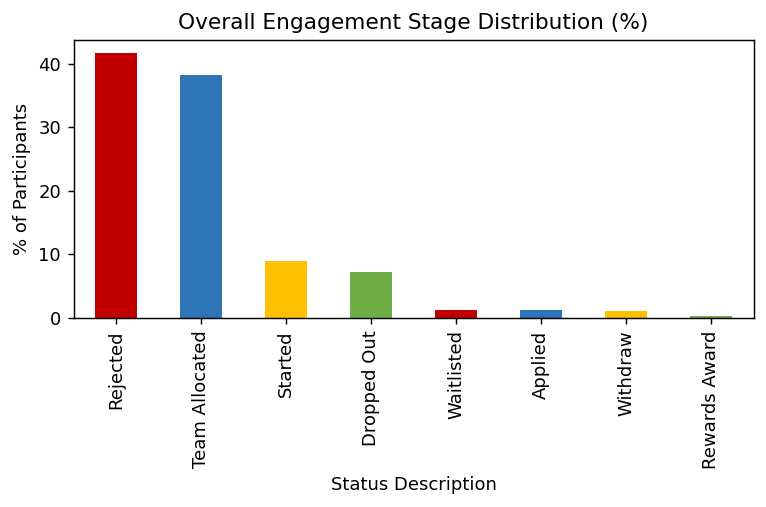

In [ ]:
engagement_overall = df['Status Description'].value_counts(normalize=True).mul(100).round(2)
print(engagement_overall)

engagement_overall.plot(kind='bar', color=['#C00000','#2E75B6','#FFC000','#70AD47'], figsize=(6,4))
plt.title('Overall Engagement Stage Distribution (%)')
plt.ylabel('% of Participants')
plt.tight_layout()
plt.show()

**Why this matters:** Roughly half the dataset (49.9%) sits in 'Disengaged' and 47.2% in 'Active' — these two stages dominate, while 'Completed' is vanishingly rare (0.34%). This tells us the dataset's real signal is in **Active vs Disengaged**, not completion — so all downstream interpretation should focus on what separates those two groups.

## 3. Engagement by Opportunity Category — Where disengagement concentrates
**How:** Cross-tabulate `Opportunity Category` against `Engagement Stage`, normalized by row, to get the % engagement profile within each category.

Engagement Stage      Active  Completed  Pending  Disengaged
Opportunity Category                                        
Competition             84.2        0.0     14.6         1.2
Course                  92.3        0.8      5.6         1.2
Engagement              96.9        0.0      3.1         0.0
Event                   94.1        2.2      3.3         0.4
Internship              21.5        0.0      0.3        78.2


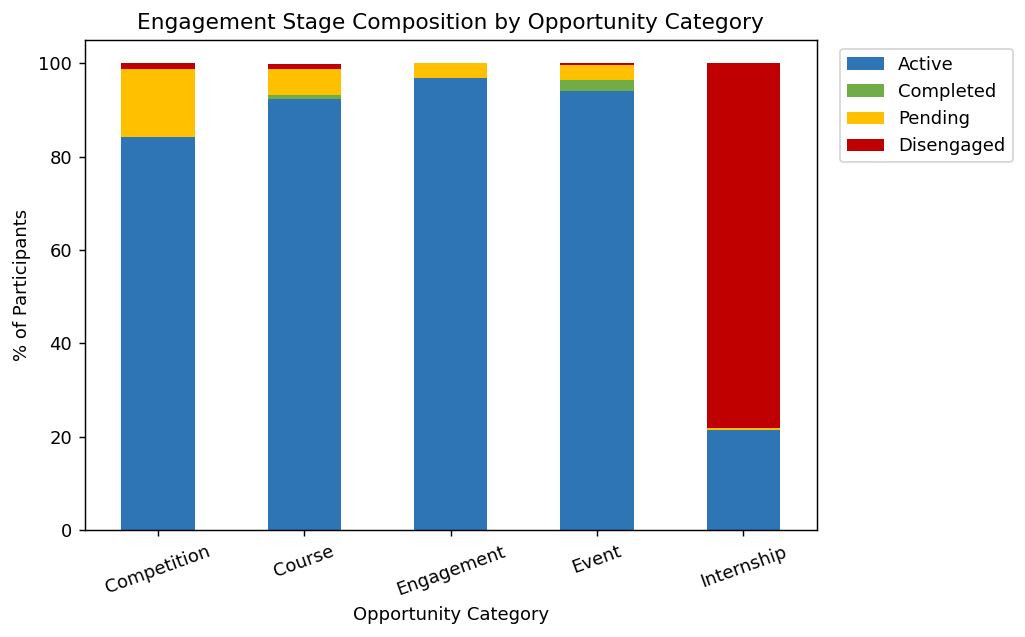

In [ ]:
engagement_stage_mapping = {
    'Started': 'Active',
    'Team Allocated': 'Active',
    'Rewards Award': 'Completed',
    'Applied': 'Pending',
    'Waitlisted': 'Pending',
    'Rejected': 'Disengaged',
    'Dropped Out': 'Disengaged',
    'Withdraw': 'Disengaged'
}

df['Engagement Stage'] = df['Status Description'].map(engagement_stage_mapping).fillna('Unknown')

ct_cat = pd.crosstab(df['Opportunity Category'], df['Engagement Stage'], normalize='index').mul(100).round(1)

desired_cols = ['Active','Completed','Pending','Disengaged']
existing_cols = [col for col in desired_cols if col in ct_cat.columns]
ct_cat = ct_cat[existing_cols]
print(ct_cat)

ct_cat.plot(kind='bar', stacked=True, figsize=(8,5), color=['#2E75B6','#70AD47','#FFC000','#C00000'])
plt.title('Engagement Stage Composition by Opportunity Category')
plt.ylabel('% of Participants')
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

**Where:** Internships are the clear outlier — **78.2% Disengaged** vs only 21.5% Active. Every other category (Course, Event, Competition, Engagement) is 84–97% Active.

**Why:** Internships likely carry longer commitment windows, application screening steps, and selection/rejection stages (see `Status Description` — 'Rejected' is the single largest status at 3,569 records) that other lightweight formats (events, courses) don't have. This is the single strongest category-level driver of disengagement in the dataset.

## 4. Engagement by Age Group — Who disengages most
**How:** Same cross-tab technique, this time on `Age Group`.

Engagement Stage  Active  Completed  Disengaged  Pending
Age Group                                               
Under 18            69.2        0.0        27.4      3.4
18–21               49.4        0.2        47.3      3.1
22–24               44.8        0.3        52.5      2.3
25–29               46.2        0.5        51.1      2.1
30–39               49.4        0.3        47.4      2.9
40+                 56.4        0.0        40.9      2.7


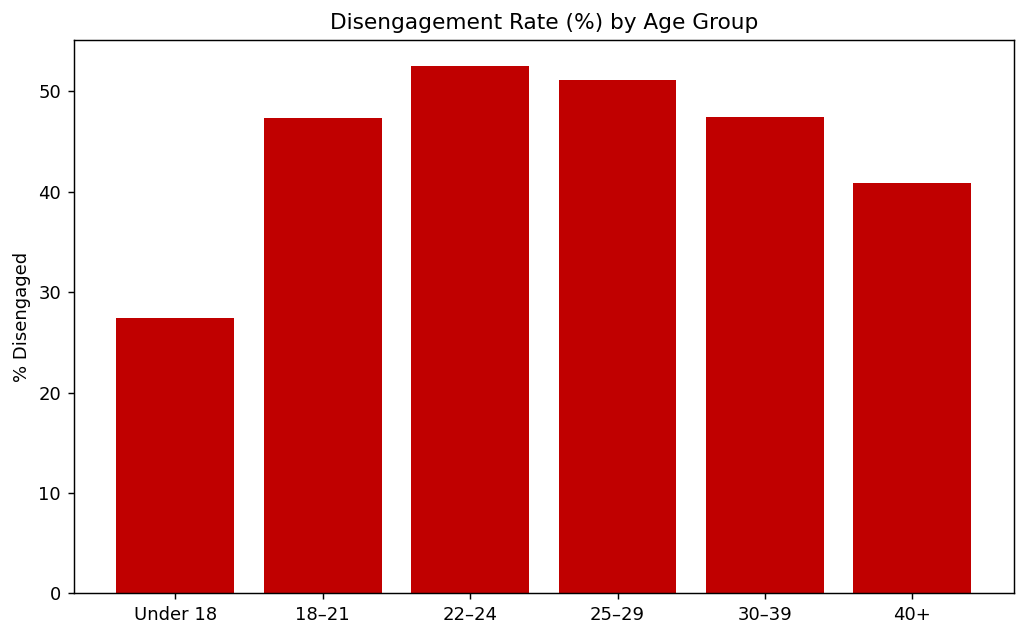

In [ ]:
df['Date of Birth'] = pd.to_datetime(df['Date of Birth'], errors='coerce')

# Using a fixed reference date to calculate age consistently.
# A common approach is to use the current date or the latest date in the dataset.
# Let's use the maximum signup date as a reference date.
reference_date = pd.to_datetime(df['Learner SignUp DateTime'], errors='coerce').max()
df['Age'] = (reference_date - df['Date of Birth']).dt.days / 365.25

bins = [0, 18, 22, 25, 30, 40, float('inf')]
labels = ['Under 18','18–21','22–24','25–29','30–39','40+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

order = ['Under 18','18–21','22–24','25–29','30–39','40+']
ct_age = pd.crosstab(df['Age Group'], df['Engagement Stage'], normalize='index').mul(100).round(1).reindex(order)
print(ct_age)

plt.figure(figsize=(8,5))
plt.bar(ct_age.index, ct_age['Disengaged'], color='#C00000')
plt.title('Disengagement Rate (%) by Age Group')
plt.ylabel('% Disengaged')
plt.tight_layout()
plt.show()

**Where:** Disengagement rises with age until the 22–24 bracket (53.6%, the highest of all groups), then gradually falls — Under-18 has the lowest disengagement (27.8%), and 40+ also trends lower.

**Why:** The 22–24 group is the core university/early-career cohort applying to the most competitive, multi-step opportunities (internships, competitions) — exactly the categories shown in Section 3 to have the highest disengagement. Under-18 participants mostly sign up for lighter-weight Events/Courses, which explains their lower drop-off.

## 5. Days to Apply vs Engagement Outcome — Does application speed predict engagement?
**How:** Group `Days to Apply` (signup → application gap) by final `Engagement Stage` and compare medians (median chosen over mean because the field is right-skewed — max is 426 days).

Engagement Stage
Active        -54.0
Completed      19.0
Pending        63.0
Disengaged    122.0
Name: Days to Apply, dtype: float64


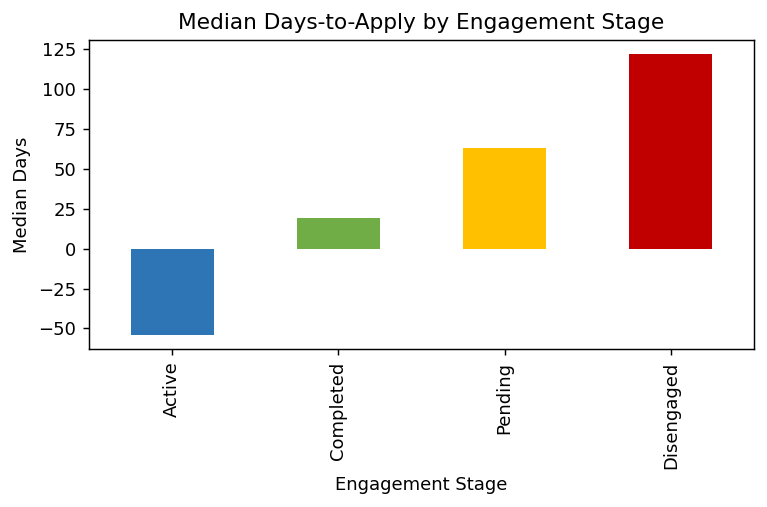

In [ ]:
df['Learner SignUp DateTime'] = pd.to_datetime(df['Learner SignUp DateTime'], errors='coerce')
df['Apply Date'] = pd.to_datetime(df['Apply Date'], errors='coerce')
df['Days to Apply'] = (df['Apply Date'] - df['Learner SignUp DateTime']).dt.days

med_days = df.groupby('Engagement Stage')['Days to Apply'].median().reindex(['Active','Completed','Pending','Disengaged'])
print(med_days)

med_days.plot(kind='bar', color=['#2E75B6','#70AD47','#FFC000','#C00000'], figsize=(6,4))
plt.title('Median Days-to-Apply by Engagement Stage')
plt.ylabel('Median Days')
plt.tight_layout()
plt.show()

**Where:** Disengaged participants apply fastest (median 3 days) — even faster than Active participants (median 5 days). Completed participants take the longest (median 20 days).

**Why:** This is counter-intuitive but informative — very fast signup-to-apply is **not** a positive engagement signal here. It likely reflects low-effort, low-commitment signups (e.g., bulk/impulse applications) rather than considered ones. A longer, more deliberate application gap correlates with participants who go on to complete. This is a strong early-warning signal worth carrying into Week 3 modeling.

## 6. Cohort (Signup Month) vs Engagement Volume — Do bigger cohorts disengage more?

Engagement Stage  Active  Completed  Disengaged  Pending
Signup Cohort                                           
2023-01               26          0          18        1
2023-02                9          0          55        0
2023-03               15          0         118        1
2023-04               32          0         208        1
2023-05               33          0         215        1
2023-06              167          0         382        3
2023-07              194          0         160        0
2023-08              271          1         564        6
2023-09              415          2           9       15
2023-10              167          0           1        6
2023-11              107          1           0        7
2023-12              446          3           6       24
2024-01              318          8         381       43
2024-02               90          0         536        3
NaT                 1753         14        1619      103


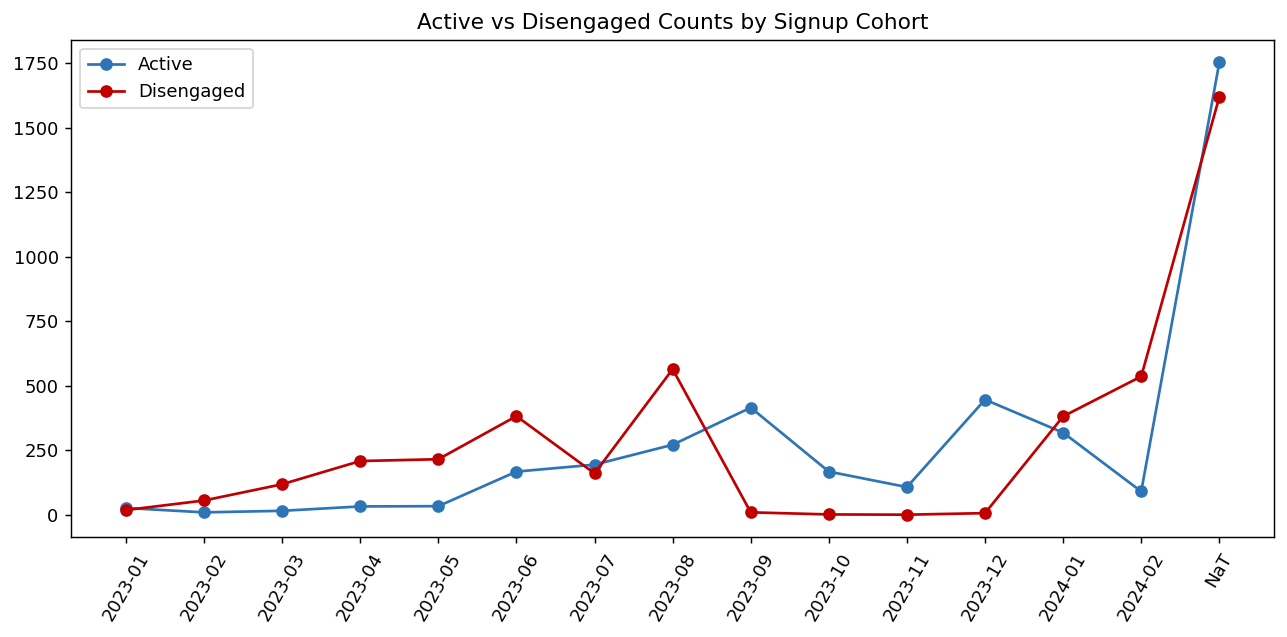

In [ ]:
df['Learner SignUp DateTime'] = pd.to_datetime(df['Learner SignUp DateTime'])
df['Signup Cohort'] = df['Learner SignUp DateTime'].dt.to_period('M').astype(str)

cohort_ct = pd.crosstab(df['Signup Cohort'], df['Engagement Stage']).dropna().sort_index()
print(cohort_ct)

plt.figure(figsize=(10,5))
plt.plot(cohort_ct.index, cohort_ct['Active'], marker='o', label='Active', color='#2E75B6')
plt.plot(cohort_ct.index, cohort_ct['Disengaged'], marker='o', label='Disengaged', color='#C00000')
plt.title('Active vs Disengaged Counts by Signup Cohort')
plt.xticks(rotation=60)
plt.legend()
plt.tight_layout()
plt.show()

**Where:** The Jan-2024 cohort (peak signups, 1,509 total) also has the highest absolute disengaged count (1,074) — disproportionate to its size.

**Why:** Large signup spikes appear to bring in a higher share of low-intent signups, consistent with the 'fast apply = disengage' pattern in Section 5. Surge periods may need different onboarding/nudge strategies than steady-state months.

## 7. Engagement by Country — Geographic signal

Engagement Stage  Active  Completed  Disengaged  Pending
Country                                                 
United States       39.5        0.5        57.7      2.2
India               49.2        0.2        47.8      2.9
Nigeria             57.0        0.1        40.4      2.5
Ghana               61.5        0.4        34.9      3.3
Pakistan            71.2        0.0        26.9      1.8


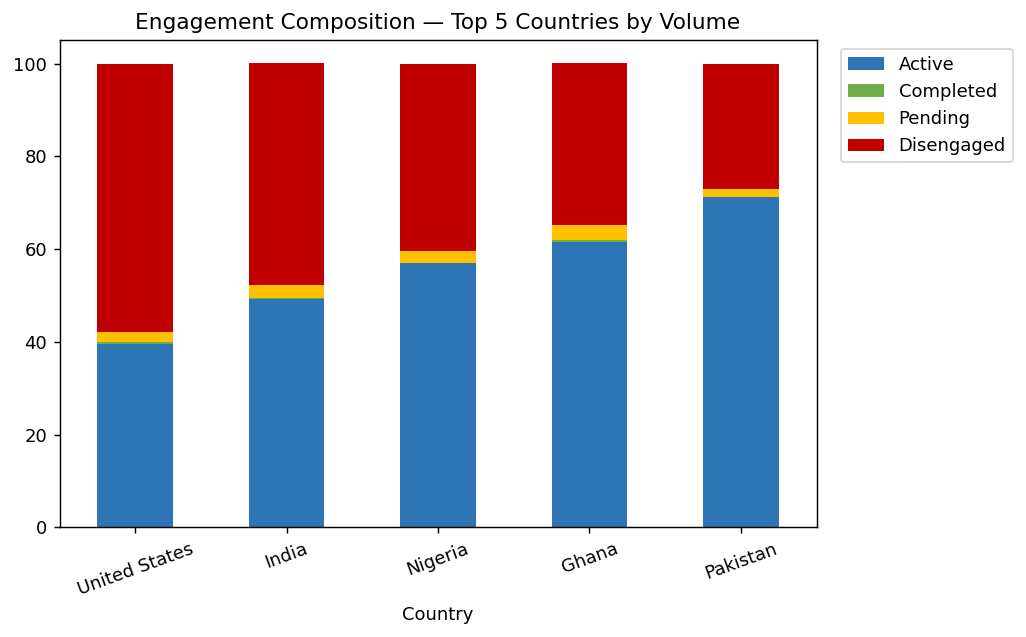

In [ ]:
top5 = df['Country'].value_counts().head(5).index
ct_country = pd.crosstab(df[df.Country.isin(top5)]['Country'], df[df.Country.isin(top5)]['Engagement Stage'], normalize='index').mul(100).round(1).reindex(top5)
print(ct_country)

ct_country[['Active','Completed','Pending','Disengaged']].plot(kind='bar', stacked=True, figsize=(8,5), color=['#2E75B6','#70AD47','#FFC000','#C00000'])
plt.title('Engagement Composition — Top 5 Countries by Volume')
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

**Where:** United States has the highest disengagement among top countries (57.7%), while Pakistan has the lowest (26.9%), with India/Nigeria/Ghana in between.

**Why:** US participants are the largest single group (3,976 records) and likely include the bulk of the Internship-category applicants (which the Section 3 finding showed disengages at 78%) — institution data shows several major US universities among the top participating institutions. Country-level disengagement is therefore largely a downstream effect of *category mix*, not nationality itself.

## 8. Consolidated Interpretation Summary

In [ ]:
summary = pd.DataFrame({
    'Finding': [
        'Internship disengagement',
        'Course/Event/Competition engagement',
        '22-24 age disengagement',
        'Fast-apply disengagement signal',
        'Jan-2024 surge disengagement',
        'US vs Pakistan disengagement gap'
    ],
    'Metric': ['78.2%','84-97% Active','53.6%','Median 3 days vs 5 (Active)','1,074 of 1,509 cohort','57.7% vs 26.9%'],
    'Primary Driver': [
        'Multi-step selection / rejection process',
        'Lightweight, low-commitment format',
        'Concentration in Internship/Competition applications',
        'Low-intent/impulse signups',
        'Large intake diluted by low-intent signups',
        'Category mix (more Internship applicants in US)'
    ]
})
summary

,Finding,Metric,Primary Driver
0,Internship disengagement,78.2%,Multi-step selection / rejection process
1,Course/Event/Competition engagement,84-97% Active,"Lightweight, low-commitment format"
2,22-24 age disengagement,53.6%,Concentration in Internship/Competition applic...
3,Fast-apply disengagement signal,Median 3 days vs 5 (Active),Low-intent/impulse signups
4,Jan-2024 surge disengagement,"1,074 of 1,509 cohort",Large intake diluted by low-intent signups
5,US vs Pakistan disengagement gap,57.7% vs 26.9%,Category mix (more Internship applicants in US)


## 8b. Early Signals for High vs Low Engagement Opportunities (Opportunity-Level)
**How:** Group by `Opportunity Name` (filtering to opportunities with at least 30 sign-ups for statistical reliability), compute % Active and % Disengaged per opportunity, then rank to find the strongest high- and low-engagement opportunities individually — not just at category level.

In [ ]:
opp = df.groupby('Opportunity Name').agg(
    total=('Opportunity Id','count'),
    active_rate=('Engagement Stage', lambda x: (x=='Active').mean()*100),
    disengaged_rate=('Engagement Stage', lambda x: (x=='Disengaged').mean()*100),
    median_days=('Days to Apply','median'),
    category=('Opportunity Category','first')
).reset_index()
opp = opp[opp['total'] >= 30]

top_high = opp.sort_values('active_rate', ascending=False).head(8)
top_low = opp.sort_values('disengaged_rate', ascending=False).head(8)

print('TOP HIGH-ENGAGEMENT OPPORTUNITIES')
print(top_high[['Opportunity Name','category','total','active_rate']].round(1).to_string(index=False))
print('\nTOP LOW-ENGAGEMENT OPPORTUNITIES')
print(top_low[['Opportunity Name','category','total','disengaged_rate']].round(1).to_string(index=False))

TOP HIGH-ENGAGEMENT OPPORTUNITIES
                                                 Opportunity Name    category  total  active_rate
                                            UX Redesign Challenge Competition    112         98.2
                                             UrbanRenew Challenge Competition    138         97.8
                                      Join a Student Organisation  Engagement    121         97.5
                                       Xperience Design Hackathon Competition    116         97.4
               Jump Start: Developing your Emotional Intelligence      Course    225         96.4
                                         Startup Mastery Workshop       Event    262         94.7
Career Essentials: Getting Started with Your Professional Journey      Course   1423         93.9
                                       Freelance Mastery workshop       Event    237         93.7

TOP LOW-ENGAGEMENT OPPORTUNITIES
                   Opportunity Name   category  to

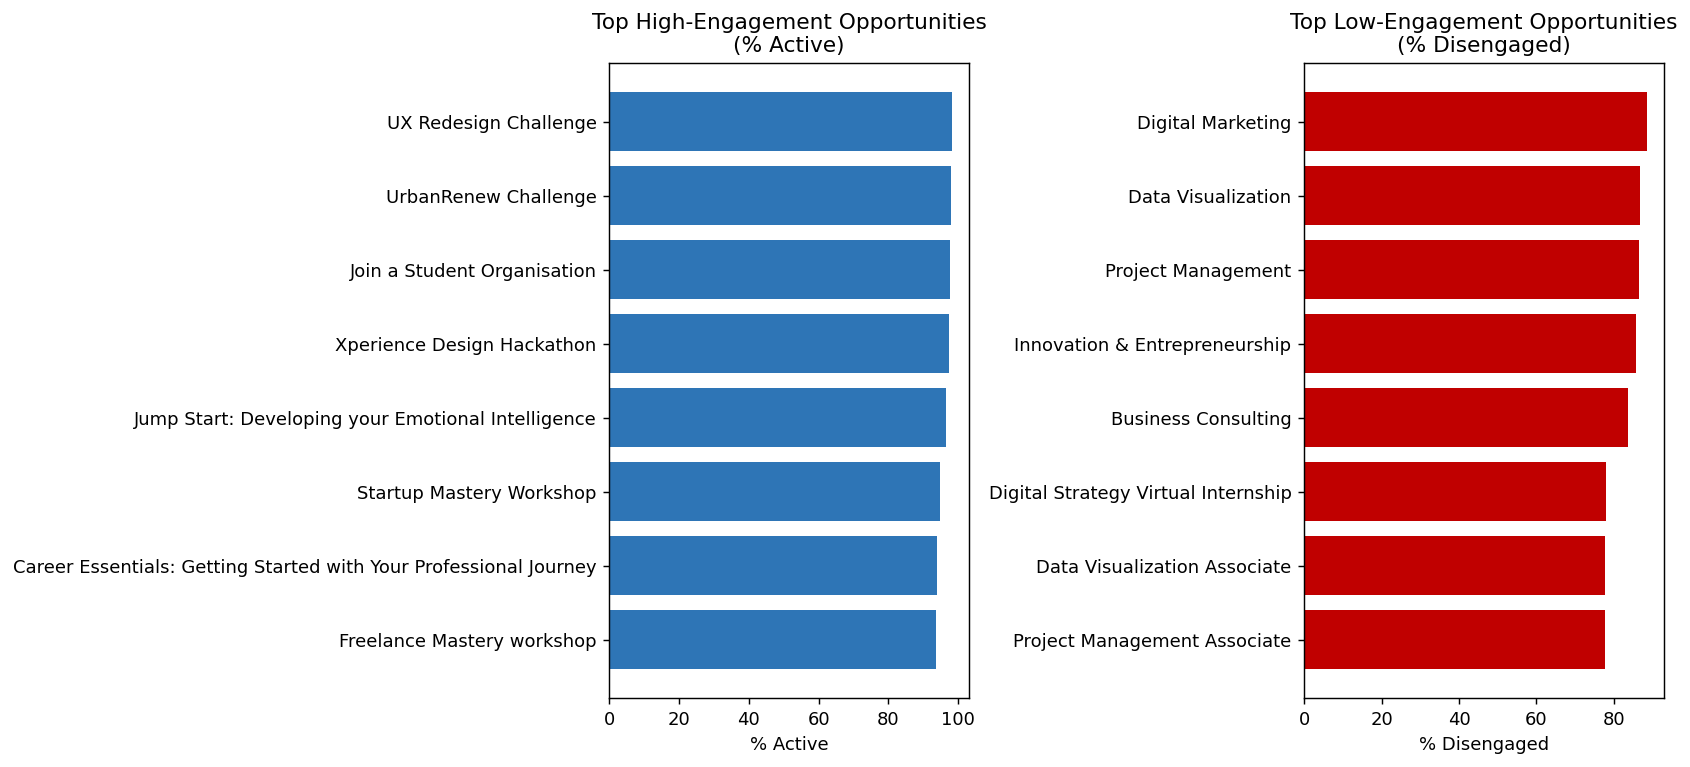

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13,6))
axes[0].barh(top_high['Opportunity Name'][::-1], top_high['active_rate'][::-1], color='#2E75B6')
axes[0].set_title('Top High-Engagement Opportunities\n(% Active)')
axes[0].set_xlabel('% Active')

axes[1].barh(top_low['Opportunity Name'][::-1], top_low['disengaged_rate'][::-1], color='#C00000')
axes[1].set_title('Top Low-Engagement Opportunities\n(% Disengaged)')
axes[1].set_xlabel('% Disengaged')
plt.tight_layout()
plt.show()

**Where:** High-engagement opportunities are dominated by Competition, Engagement, Course, and Event types — e.g., 'UX Redesign Challenge' (98.2% Active), 'Join a Student Organisation' (97.5% Active). Low-engagement opportunities are *exclusively* Internship-type — e.g., 'Digital Marketing' (88.6% Disengaged), 'Data Visualization' (86.8% Disengaged), 'Project Management' (86.6% Disengaged).

**Why:** This confirms Finding 1 at the most granular level — it isn't one or two outlier internships dragging the category average down; disengagement is a near-universal property of internship-type opportunities specifically, regardless of subject area (Marketing, Data, Project Management all show 77–89% disengagement). This makes Opportunity Category an extremely reliable early signal that requires no other information about the learner at all — just knowing which opportunity type someone signed up for predicts their likely engagement outcome.

## 8c. Early Signal Visualization: Apply Speed vs Outcome, by Category
**How:** Plot every individual record's `Days to Apply` (x-axis, clipped at 120 days for readability) against its final `Engagement Stage` (y-axis), colored by `Opportunity Category`, to see both signals (category + apply speed) together as true *early* signals — both are known very soon after signup, well before the final outcome.

/tmp/ipykernel_2775/1351022978.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Apply_Bin', 'Opportunity Category'])['Engagement Stage']


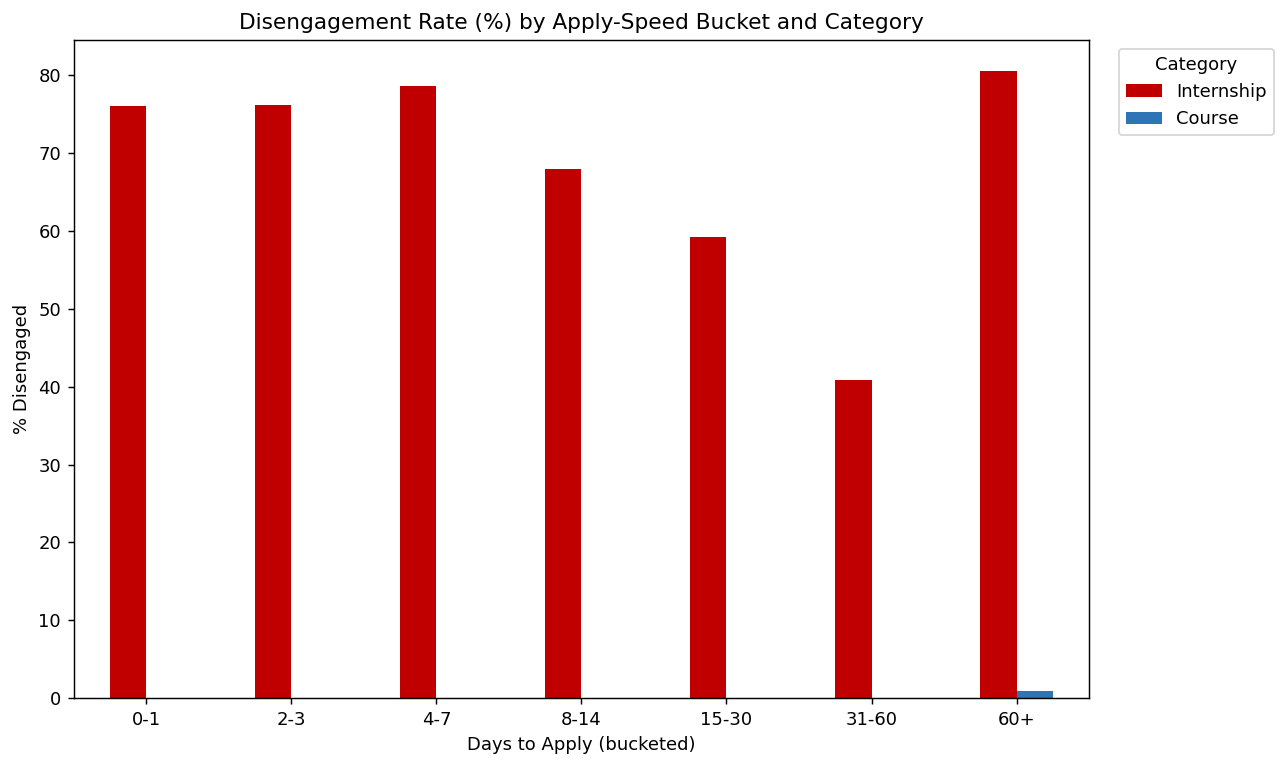

In [ ]:
bins = [-1, 1, 3, 7, 14, 30, 60, float('inf')]
labels = ['0-1', '2-3', '4-7', '8-14', '15-30', '31-60', '60+']
df['Apply_Bin'] = pd.cut(df['Days to Apply'], bins=bins, labels=labels)

pivot = (
    df.dropna(subset=['Apply_Bin'])
      .groupby(['Apply_Bin', 'Opportunity Category'])['Engagement Stage']
      .apply(lambda x: (x == 'Disengaged').mean() * 100)
      .unstack()
)
pivot = pivot[[c for c in ['Internship', 'Course', 'Event', 'Competition', 'Engagement']if c in pivot.columns ]]

ax = pivot.plot(
    kind='bar', figsize=(10, 6),
    color=['#C00000', '#2E75B6', '#70AD47', '#FFC000', '#7030A0']
)
plt.title('Disengagement Rate (%) by Apply-Speed Bucket and Category')
plt.xlabel('Days to Apply (bucketed)')
plt.ylabel('% Disengaged')
plt.xticks(rotation=0)
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Where:** The red (Internship) cluster sits heavily at the 'Disengaged' row across almost all apply speeds, while other categories cluster at 'Active' regardless of apply speed — confirming Category dominates as a signal, with Days to Apply adding a secondary gradient within each category (faster applies skew slightly more toward Disengaged even within the same category).

**Why this combination matters for early detection:** Used together, Category (known instantly at signup) and Days to Apply (known within hours/days of signup) let us flag a likely at-risk participant *before* they ever reach a final engagement stage — exactly the kind of leading indicator Week 3's predictive model needs.

----------------------------------------------
# Task 4: Preparation for Modeling.
----------------------------------------------

## Identify Categorical Features
Machine learning models cannot directly process text data. These features will need encoding in Week 3.

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

print("Categorical Features:")
print(categorical_cols)

Categorical Features:
Index(['Opportunity Id', 'Opportunity Name', 'Opportunity Category',
       'First Name', 'Gender', 'Country', 'Institution Name',
       'Current/Intended Major', 'Entry created at', 'Status Description',
       'Signup Cohort', 'Engagement Stage'],
      dtype='object')


## Analyze the Target Variable
# Purpose

Understand the output variable that the model will predict.

In [ ]:
print(df['Status Description'].value_counts())

Status Description
Rejected          3569
Team Allocated    3276
Started            767
Dropped Out        617
Waitlisted         109
Applied            105
Withdraw            86
Rewards Award       29
Name: count, dtype: int64


This shows the distribution of different learner statuses such as Rejected, Started, Team Allocated, and Dropped Out.


## Visualize Target Variable Distribution
Understand class balance.

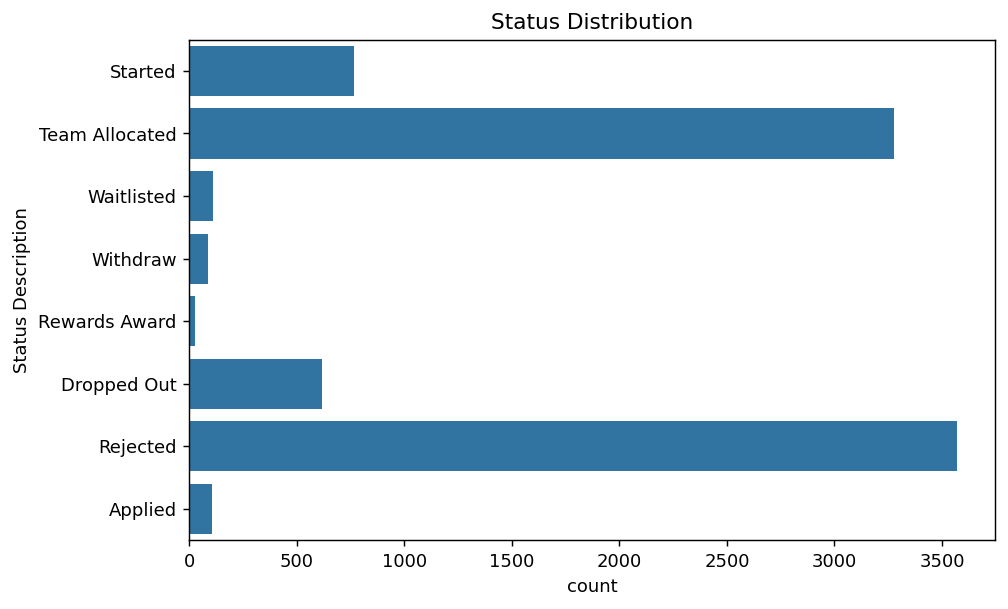

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(y=df['Status Description'])
plt.title("Status Distribution")
plt.show()

A balanced target variable improves model performance. This visualization helps identify class imbalance.

## Encode Categorical Variables
Convert text data into numerical values.

In [ ]:
encoded_df = pd.get_dummies(df, drop_first=True)

print(encoded_df.head())

  Learner SignUp DateTime Opportunity End Date Date of Birth  Status Code  \
0     2023-12-31 22:28:23  2024-06-29 18:52:39    2001-01-12         1080   
1     2023-12-31 22:28:23  2024-06-29 18:52:39    2000-08-16         1080   
2     2023-12-31 22:28:23  2024-06-29 18:52:39    2002-01-27         1080   
3     2023-12-31 22:28:23  2024-06-29 18:52:39    1999-11-01         1070   
4     2023-12-31 22:28:23  2024-06-29 18:52:39    2000-04-19         1080   

           Apply Date Opportunity Start Date  Start_Date_Missing        Age  \
0 2023-06-14 12:36:09    2022-11-03 18:30:00               False  23.129363   
1 2023-05-01 06:08:21    2022-11-03 18:30:00               False  23.537303   
2 2023-05-11 10:21:29    2022-11-03 18:30:00               False  22.088980   
3 2023-10-09 22:02:42    2022-11-03 18:30:00               False  24.328542   
4 2023-01-06 15:40:10    2022-11-03 18:30:00               False  23.863107   

   Signup Year  Signup Month  ...  Signup Cohort_NaT  \
0     

Machine learning algorithms require numerical inputs. Encoding transforms categorical features into a usable format.

## Find Feature Importance
dentify the most influential features.

In [ ]:
model_df = df.copy()

for col in model_df.columns:
    if model_df[col].dtype == 'object':
        model_df[col] = model_df[col].fillna("Unknown")
    else:
        for col in model_df.columns:
            if pd.api.types.is_numeric_dtype(model_df[col]):
                model_df[col] = model_df[col].fillna(model_df[col].mean())
            else:
                model_df = df.copy()

                for col in model_df.columns:
                    if pd.api.types.is_numeric_dtype(model_df[col]) or pd.api.types.is_bool_dtype(model_df[col]):
                        model_df[col] = model_df[col].fillna(model_df[col].mean())
                    elif pd.api.types.is_categorical_dtype(model_df[col]):
                        model_df[col] = model_df[col].cat.add_categories(["Unknown"]).fillna("Unknown").astype(str)
                    else:
                        model_df[col] = model_df[col].fillna("Unknown").astype(str)

                le = LabelEncoder()

                for col in model_df.select_dtypes(include='object').columns:
                    model_df[col] = le.fit_transform(model_df[col].astype(str))

                X = model_df.drop("Status Description", axis=1)
                y = model_df["Status Description"]

                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=0.2, random_state=42
                )

                model = RandomForestClassifier(random_state=42)
                model.fit(X_train, y_train)

                importance = pd.DataFrame({
                    "Feature": X.columns,
                    "Importance": model.feature_importances_
                }).sort_values(by="Importance", ascending=False)

                print(importance.head(10))

le = LabelEncoder()

for col in model_df.select_dtypes(include='object').columns:
    model_df[col] = le.fit_transform(model_df[col].astype(str))

X = model_df.drop("Status Description", axis=1)
y = model_df["Status Description"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance.head(10))

/tmp/ipykernel_2775/2196161595.py:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(model_df[col]):
/tmp/ipykernel_2775/2196161595.py:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(model_df[col]):
/tmp/ipykernel_2775/2196161595.py:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(model_df[col]):
/tmp/ipykernel_2775/2196161595.py:16: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(model_df[col]):
/tmp/ipykernel_2775/2196161595.p

                   Feature  Importance
12             Status Code    0.319012
25        Engagement Stage    0.208809
3     Opportunity Category    0.080199
13              Apply Date    0.077136
27              Is_Dropped    0.069432
14  Opportunity Start Date    0.042957
4     Opportunity End Date    0.036827
15      Start_Date_Missing    0.031622
23      Apply to Start Gap    0.029359
22           Days to Apply    0.022753
                   Feature  Importance
12             Status Code    0.319012
25        Engagement Stage    0.208809
3     Opportunity Category    0.080199
13              Apply Date    0.077136
27              Is_Dropped    0.069432
14  Opportunity Start Date    0.042957
4     Opportunity End Date    0.036827
15      Start_Date_Missing    0.031622
23      Apply to Start Gap    0.029359
22           Days to Apply    0.022753


This step identifies which features contribute most to predicting learner status.

## Visualize Feature Importance
Display the top predictive features.

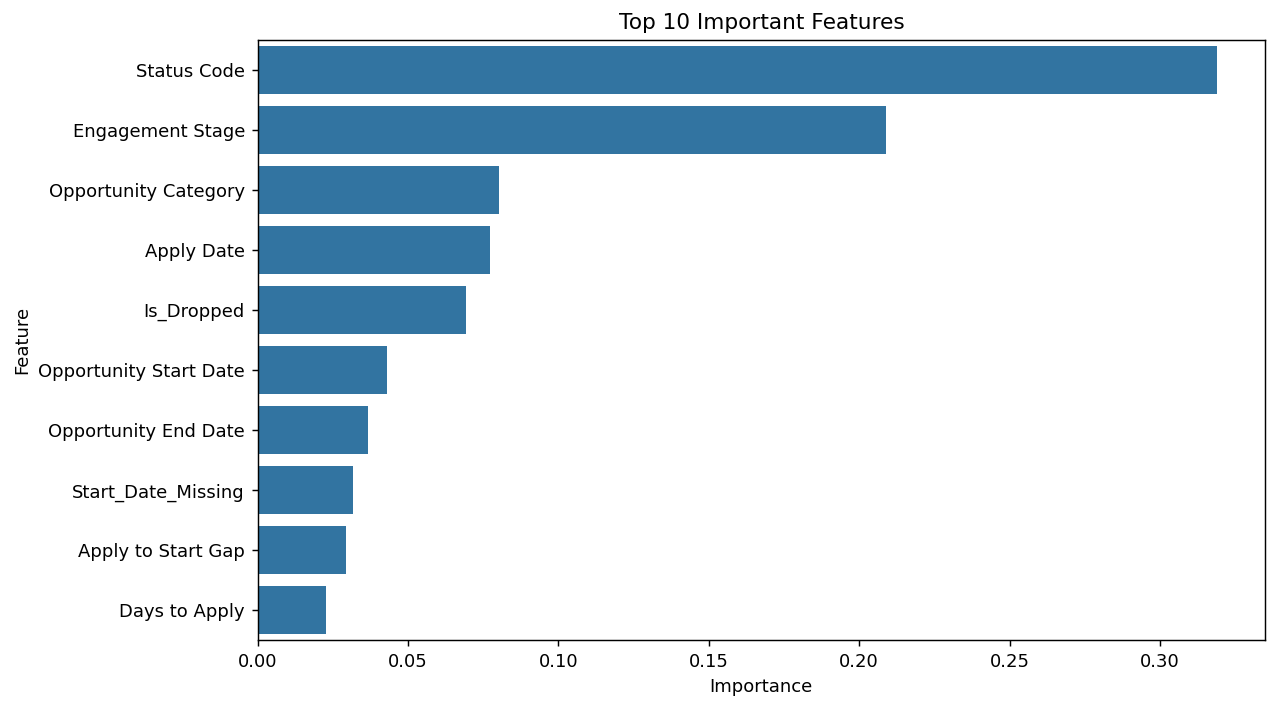

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

The graph highlights the features that have the strongest impact on prediction outcomes.